# Block 13 — Long/Short & Risk-Scaled Portfolio Extensions

## Purpose

Extend the **frozen** Blocks 1–12 research programme without modifying or re-optimizing the original signal.

This block asks whether the information in the frozen state-dependent sector signal supports a capital-efficient long/short portfolio in which **bearish sectors form a short book and help finance increased exposure to favourable sectors**.

### Pre-specified experiments

1. **Bearish-state short diagnostic** — test whether bearish sectors subsequently underperform.
2. **Fixed net-100 long/short portfolios** — 120/20, 130/30 and 150/50.
3. **Market-neutral diagnostic** — 50/50 long/short.
4. **Risk-scaled variants** — scale frozen portfolios using lagged realized volatility.
5. **Financing, borrow and transaction-cost sensitivity**.
6. **Concentration / gross / net / short-exposure diagnostics**.

### State interpretation

- `BEARISH` → short candidate.
- `EARLY_REVERSAL` → cover short first; do not immediately create a large long.
- `CONFIRMED_TREND` / `NORMAL_POSITIVE_TREND` → long candidate.
- `PULLBACK_ACCUMULATION` → favourable long state.
- `PROFIT_TAKING` → retain long eligibility but reduce its allocation score.

No indicator parameters, state definitions, or historical signal rules are optimized in this block.


In [1]:
# ============================================================
# BLOCK 13.1 — SETUP & PROJECT PATHS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

# Use the exact project path convention already proven to work in Block 12.
PROJECT_ROOT = Path(
    r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/"
    r"State-Dependent U.S. Equity Sector Rotation - "
    r"A Systematic Framework for Trend-Based Active Sector Allocation"
)

DIRS = {
    "root": PROJECT_ROOT,
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
    "reports": PROJECT_ROOT / "outputs" / "reports",
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "outputs": PROJECT_ROOT / "outputs",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = DIRS["outputs"]

SECTOR_COLS = [
    "XLC","XLY","XLP","XLE","XLF","XLV",
    "XLI","XLK","XLB","XLRE","XLU"
]

PPY = 52
RF = 0.0

# Pre-specified — not optimized.
FIXED_BOOKS = {
    "LS_120_20": (1.20, 0.20),
    "LS_130_30": (1.30, 0.30),
    "LS_150_50": (1.50, 0.50),
    "LS_Market_Neutral_50_50": (0.50, 0.50),
}

MAX_SINGLE_LONG_WEIGHT = 0.30
MAX_SINGLE_SHORT_ABS_WEIGHT = 0.15
MAX_GROSS_EXPOSURE = 2.00

TRANSACTION_COST_BPS = 5.0
FINANCING_RATE_ANNUAL = 0.04
SHORT_BORROW_RATE_ANNUAL = 0.01

VOL_LOOKBACK_WEEKS = 26
VOL_TARGETS = [0.10, 0.12, 0.15]
VOL_LEVERAGE_CAP = 2.0

print("Project root exists:", PROJECT_ROOT.exists())
print("Project root:")
print(PROJECT_ROOT)
print("\nManifest dir:")
print(DIRS["manifests"])
print("\nOutput dir:")
print(OUTPUT_DIR)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Confirmed Block 12 project path not found: {PROJECT_ROOT}"
    )


Mounted at /content/drive
Project root exists: True
Project root:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation

Manifest dir:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/manifests

Output dir:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs


In [2]:
# ============================================================
# BLOCK 13.2 — MANIFEST-GROUNDED FILE RESOLUTION
# ============================================================

def load_manifest(filename):
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block2 = load_manifest("block_2_universe_data_weights.json")
block4 = load_manifest("block_4_state_active_weights.json")
block5 = load_manifest("block_5_portfolio_engine.json")

print("Loaded Block 2, 4 and 5 manifests.")


def resolve_from_manifest(mapping, keys, label, filename_tokens=None):
    """
    Resolve an artifact from a saved_files mapping using the same robust
    approach that worked in Blocks 11–12.
    """
    # Exact manifest keys first.
    for key in keys:
        if key in mapping:
            p = Path(mapping[key])
            if p.exists():
                print(f"Resolved {label} from key '{key}':")
                print(" ", p)
                return p

            # If an old absolute path is stale, search by basename under project.
            hits = list(PROJECT_ROOT.rglob(p.name))
            if hits:
                hit = sorted(
                    hits,
                    key=lambda x: x.stat().st_mtime,
                    reverse=True,
                )[0]
                print(f"Resolved {label} by manifest basename '{key}':")
                print(" ", hit)
                return hit

    # Filename-token fallback over manifest values.
    if filename_tokens:
        tokens = [t.lower() for t in filename_tokens]

        for key, value in mapping.items():
            if not isinstance(value, str):
                continue

            p = Path(value)
            name = p.name.lower()

            if all(token in name for token in tokens):
                if p.exists():
                    print(f"Resolved {label} from filename match '{key}':")
                    print(" ", p)
                    return p

                hits = list(PROJECT_ROOT.rglob(p.name))
                if hits:
                    hit = sorted(
                        hits,
                        key=lambda x: x.stat().st_mtime,
                        reverse=True,
                    )[0]
                    print(f"Resolved {label} by filename fallback '{key}':")
                    print(" ", hit)
                    return hit

    raise FileNotFoundError(
        f"Could not resolve {label}.\n"
        f"Available manifest keys: {list(mapping.keys())}\n"
        f"Tried keys: {keys}\n"
        f"Filename tokens: {filename_tokens}"
    )


STATE_PATH = resolve_from_manifest(
    block4["saved_files"],
    [
        "state_long",
        "weekly_state_dependent_state_long",
        "canonical_state_long",
        "state_active_weights_long",
        "canonical_active_weights_long",
    ],
    "Block 4 state history",
    filename_tokens=["state", "long"],
)

STRATEGIC_PATH = resolve_from_manifest(
    block2["saved_files"],
    [
        "strategic_weights",
        "weekly_strategic_weights",
    ],
    "strategic weights",
    filename_tokens=["strategic", "weights"],
)

SECTOR_RETURNS_PATH = resolve_from_manifest(
    block5["saved_files"],
    [
        "sector_holding_returns",
        "weekly_execution_holding_returns_sectors",
        "holding_returns_sectors",
    ],
    "sector holding returns",
    filename_tokens=["holding", "returns", "sectors"],
)

CORE_RETURNS_PATH = resolve_from_manifest(
    block5["saved_files"],
    [
        "portfolio_returns",
        "weekly_portfolio_returns_core_strategies",
        "core_strategy_returns",
    ],
    "core portfolio returns",
    filename_tokens=["portfolio", "returns", "core"],
)

# Calendar is useful but not strictly required because a fallback exists later.
try:
    CALENDAR_PATH = resolve_from_manifest(
        block2["saved_files"],
        [
            "weekly_signal_execution_calendar",
            "signal_execution_calendar",
        ],
        "signal/execution calendar",
        filename_tokens=["signal", "execution", "calendar"],
    )
except FileNotFoundError:
    CALENDAR_PATH = None
    print("Signal/execution calendar not resolved; Block 13.4 fallback will be used.")

print("\n" + "=" * 72)
print("BLOCK 13 INPUTS")
print("=" * 72)
print("State          :", STATE_PATH)
print("Strategic      :", STRATEGIC_PATH)
print("Sector returns :", SECTOR_RETURNS_PATH)
print("Core returns   :", CORE_RETURNS_PATH)
print("Calendar       :", CALENDAR_PATH)


Loaded Block 2, 4 and 5 manifests.
Resolved Block 4 state history from key 'canonical_active_weights_long':
  /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_active_weights_long.parquet
Resolved strategic weights from key 'strategic_weights':
  /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_signal_strategic_sector_weights.parquet
Resolved sector holding returns from key 'sector_holding_returns':
  /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_execution_holding_returns_sectors.parquet
Resolved core portfolio returns from key 'portfolio_re

In [3]:
# ============================================================
# BLOCK 13.3 — LOAD & NORMALIZE CANONICAL INPUTS
# ============================================================

state_long = pd.read_parquet(STATE_PATH).copy()
strategic = pd.read_parquet(STRATEGIC_PATH).copy()
sector_returns = pd.read_parquet(SECTOR_RETURNS_PATH).copy()
core_returns = pd.read_parquet(CORE_RETURNS_PATH).copy()

def normalize_dt_index(df):
    x = df.copy()
    if "date" in x.columns:
        x["date"] = pd.to_datetime(x["date"])
    elif "signal_date" in x.columns:
        x["date"] = pd.to_datetime(x["signal_date"])
    elif "execution_date" in x.columns:
        x["date"] = pd.to_datetime(x["execution_date"])
    else:
        x.index = pd.to_datetime(x.index)
        x.index.name = "date"
    return x

state_long = normalize_dt_index(state_long)
strategic = normalize_dt_index(strategic)
sector_returns = normalize_dt_index(sector_returns)
core_returns = normalize_dt_index(core_returns)

if "date" in strategic.columns:
    strategic = strategic.set_index("date")
if "date" in sector_returns.columns:
    sector_returns = sector_returns.set_index("date")
if "date" in core_returns.columns:
    core_returns = core_returns.set_index("date")

strategic = strategic[SECTOR_COLS].sort_index()
sector_returns = sector_returns[SECTOR_COLS].sort_index()
core_returns = core_returns.sort_index()

required_state_cols = {"date", "ticker", "strategic_state"}
missing = required_state_cols.difference(state_long.columns)
if missing:
    raise KeyError(f"State file missing required columns: {sorted(missing)}")

state_long["date"] = pd.to_datetime(state_long["date"])
state_long = state_long.sort_values(["date", "ticker"])

print("State columns:", list(state_long.columns))
print("Strategic range:", strategic.index.min(), "to", strategic.index.max())
print("Return range:", sector_returns.index.min(), "to", sector_returns.index.max())
print("Core strategies:", list(core_returns.columns))


State columns: ['date', 'ticker', 'close', 'smoothed_price', 'fast_ma', 'slow_ma', 'oscillator', 'signal_line', 'spread', 'raw_spread_std', 'spread_std', 'upper_bb', 'lower_bb', 'oscillator_slope', 'signal_slope', 'osc_rising', 'osc_falling', 'signal_rising', 'signal_falling', 'osc_flat', 'signal_flat', 'osc_turns_red', 'cross_below_zero', 'signal_cross_above_zero', 'osc_cross_above_signal', 'osc_cross_above_lower_bb', 'osc_cross_below_upper_bb', 'indicator_ready', 'tsmom_12m_return', 'tsmom_sign', 'signal_observation_date', 'execution_date', 'execution_weekday', 'pine_zone_mode', 'pine_zone_state', 'early_reversal_exit_mode', 'early_reversal_saw_below_bb', 'pullback_saw_above_bb', 'position_held', 'strategic_state', 'tactical_state', 'early_reversal_entry_intersection', 'pullback_entry_intersection', 'start_early_reversal', 'end_early_reversal', 'start_pullback', 'end_pullback', 'start_profit_taking', 'end_profit_taking', 'position_entry_event', 'position_exit_event', 'previous_active

In [4]:
# ============================================================
# BLOCK 13.4 — ALIGN SIGNAL DATES TO EXECUTION/HOLDING RETURNS
# ============================================================

# Preferred: use the canonical signal-observation -> execution mapping
# from Block 2. The actual saved calendar schema is:
#
#   signal_observation_date
#   signal_observation_weekday
#   execution_date
#   execution_weekday
#   calendar_days_signal_to_execution
#
# We therefore resolve those exact fields first and retain robust
# fallbacks for harmless naming differences.

if CALENDAR_PATH is not None:
    cal = pd.read_parquet(CALENDAR_PATH).copy()

    print("Calendar columns:", list(cal.columns))

    signal_candidates = [
        "signal_observation_date",
        "actual_signal_date",
        "signal_session_date",
        "signal_trading_date",
        "signal_date",
        "date",
        "week",
        "signal_label",
    ]

    execution_candidates = [
        "execution_date",
        "rebalance_execution_date",
        "next_execution_date",
        "rebalance_date",
        "next_trading_session",
        "execution_session",
    ]

    sig_col = next(
        (c for c in signal_candidates if c in cal.columns),
        None,
    )

    exe_col = next(
        (c for c in execution_candidates if c in cal.columns),
        None,
    )

    if sig_col is None or exe_col is None:
        raise KeyError(
            "Could not identify signal/execution columns in calendar.\n"
            f"Available columns: {list(cal.columns)}\n"
            f"Signal candidates tried: {signal_candidates}\n"
            f"Execution candidates tried: {execution_candidates}"
        )

    mapping = cal[[sig_col, exe_col]].dropna().copy()
    mapping[sig_col] = pd.to_datetime(mapping[sig_col])
    mapping[exe_col] = pd.to_datetime(mapping[exe_col])

    # One signal observation should map to one execution session.
    duplicate_signal = mapping.duplicated(subset=[sig_col], keep=False)
    if duplicate_signal.any():
        check = (
            mapping.loc[duplicate_signal]
            .groupby(sig_col)[exe_col]
            .nunique()
        )
        if (check > 1).any():
            raise AssertionError(
                "A signal observation maps to multiple execution dates."
            )

    mapping = (
        mapping
        .drop_duplicates(subset=[sig_col])
        .set_index(sig_col)[exe_col]
    )

    state_long["execution_date"] = state_long["date"].map(mapping)

    print("Resolved signal observation column:", sig_col)
    print("Resolved execution column:", exe_col)

else:
    # Fallback: map each signal observation to the first available
    # realized holding-return index strictly after the signal date.
    realized_dates = pd.DatetimeIndex(
        sector_returns.index
    ).sort_values()

    def next_realized_date(d):
        pos = realized_dates.searchsorted(
            pd.Timestamp(d),
            side="right",
        )
        return (
            realized_dates[pos]
            if pos < len(realized_dates)
            else pd.NaT
        )

    state_long["execution_date"] = (
        state_long["date"]
        .map(next_realized_date)
    )

state_long = (
    state_long
    .dropna(subset=["execution_date"])
    .copy()
)

state_long["execution_date"] = pd.to_datetime(
    state_long["execution_date"]
)

# ------------------------------------------------------------
# TIMING AUDIT
# ------------------------------------------------------------

if not (
    state_long["execution_date"]
    > state_long["date"]
).all():

    bad = state_long.loc[
        ~(
            state_long["execution_date"]
            > state_long["date"]
        ),
        ["date", "execution_date", "ticker"],
    ].head(20)

    raise AssertionError(
        "Look-ahead timing violation detected:\n"
        f"{bad}"
    )

lag_days = (
    state_long["execution_date"]
    - state_long["date"]
).dt.days

print("\nTiming audit passed.")
print("Mapped state rows:", len(state_long))
print("First signal:", state_long["date"].min())
print("First execution:", state_long["execution_date"].min())
print("Minimum calendar-day lag:", int(lag_days.min()))
print("Median calendar-day lag:", float(lag_days.median()))
print("Maximum calendar-day lag:", int(lag_days.max()))


Calendar columns: ['signal_observation_date', 'signal_observation_weekday', 'execution_date', 'execution_weekday', 'calendar_days_signal_to_execution']
Resolved signal observation column: signal_observation_date
Resolved execution column: execution_date

Timing audit passed.
Mapped state rows: 3971
First signal: 2019-06-21 00:00:00
First execution: 2019-06-24 00:00:00
Minimum calendar-day lag: 3
Median calendar-day lag: 3.0
Maximum calendar-day lag: 4


In [5]:
# ============================================================
# BLOCK 13.5 — BEARISH-STATE SHORT DIAGNOSTIC
# ============================================================

# IMPORTANT INDEX CONVENTION
# --------------------------
# Block 5's saved weekly sector holding-return matrix is indexed by the
# SIGNAL DATE (Friday-labelled signal observation), even though each row
# contains the return earned from the subsequent execution session to the
# following execution session.
#
# Therefore:
#   state signal date  ->  row in sector_returns
#
# `execution_date` remains useful for the no-look-ahead audit, but it is
# NOT the join key for the saved Block 5 holding-return matrix.

diagnostic = state_long[
    ["date", "execution_date", "ticker", "strategic_state"]
].copy()

ret_long = (
    sector_returns
    .stack(future_stack=True)
    .rename("forward_return")
    .reset_index()
)

# Normalize the first index column to the canonical signal-date label.
ret_long.columns = ["date", "ticker", "forward_return"]
ret_long["date"] = pd.to_datetime(ret_long["date"])

diagnostic = diagnostic.merge(
    ret_long,
    on=["date", "ticker"],
    how="left",
).dropna(subset=["forward_return"])

if diagnostic.empty:
    raise AssertionError(
        "Bearish-state diagnostic produced no matched forward returns. "
        "Check the Block 5 sector-return index convention."
    )

diagnostic["is_bearish"] = (
    diagnostic["strategic_state"].eq("BEARISH")
)

bearish_diag = (
    diagnostic.groupby("is_bearish")["forward_return"]
    .agg(["count", "mean", "median", "std"])
)

bearish_diag["annualized_mean_approx"] = (
    bearish_diag["mean"] * PPY
)

bearish_mean = diagnostic.loc[
    diagnostic["is_bearish"],
    "forward_return",
].mean()

nonbearish_mean = diagnostic.loc[
    ~diagnostic["is_bearish"],
    "forward_return",
].mean()

spread = nonbearish_mean - bearish_mean

print("Bearish-state forward-return diagnostic")
display(bearish_diag)
print(
    "Non-bearish minus bearish mean weekly return:",
    spread,
)
print(
    "Matched signal weeks:",
    diagnostic["date"].nunique(),
)

bearish_diag.to_csv(
    OUTPUT_DIR
    / "block_13_bearish_state_forward_return_diagnostic.csv"
)


Bearish-state forward-return diagnostic


,count,mean,median,std,annualized_mean_approx
is_bearish,,,,,
False,1978,0.003020,0.003346,0.026986,0.157028
True,1982,0.002011,0.004378,0.035189,0.104590


Non-bearish minus bearish mean weekly return: 0.001008435738814676
Matched signal weeks: 360


In [6]:
# ============================================================
# BLOCK 13.6 — STATE SCORES & LONG/SHORT ELIGIBILITY
# ============================================================

# Tactical state is used only to rank/size already-long-eligible sectors.
if "tactical_state" not in state_long.columns:
    state_long["tactical_state"] = "NONE"


def long_score(row):
    strategic_state = str(row["strategic_state"])
    tactical_state = str(row["tactical_state"])

    if strategic_state == "BEARISH":
        return 0.0

    # Early reversal primarily represents short covering / cautious re-entry.
    if strategic_state == "EARLY_REVERSAL":
        return 0.25

    # Confirmed and normal positive trends are fully long-eligible.
    base = 1.00

    if tactical_state == "PULLBACK_ACCUMULATION":
        base += 0.50
    elif tactical_state == "PROFIT_TAKING":
        base -= 0.25

    return max(base, 0.0)


state_long["long_score"] = state_long.apply(
    long_score,
    axis=1,
)

state_long["short_score"] = np.where(
    state_long["strategic_state"].eq("BEARISH"),
    1.0,
    0.0,
)

# Keep BOTH signal date and execution date.
# Signal date is the portfolio/return index used by Block 5.
# Execution date is retained for the timing audit and documentation.
state_exec = state_long[
    [
        "date",
        "execution_date",
        "ticker",
        "strategic_state",
        "tactical_state",
        "long_score",
        "short_score",
    ]
].copy()

print(
    "Long eligible rows:",
    int((state_exec["long_score"] > 0).sum()),
)
print(
    "Short eligible rows:",
    int((state_exec["short_score"] > 0).sum()),
)


Long eligible rows: 1987
Short eligible rows: 1984


In [7]:
# ============================================================
# BLOCK 13.7 — CONSTRAINED ALLOCATION HELPERS
# ============================================================

def capped_proportional_allocation(
    base_weights,
    target_total,
    cap_abs,
):
    """
    Allocate non-negative target_total proportionally to base_weights
    subject to a per-name absolute cap.

    If the requested book exposure is infeasible because too few names are
    eligible under the cap, the residual remains unallocated rather than
    violating the concentration constraint.
    """
    s = pd.Series(base_weights, dtype=float).clip(lower=0.0)
    out = pd.Series(0.0, index=s.index)

    if target_total <= 0 or s.sum() <= 0:
        return out

    remaining = float(target_total)
    active = s[s > 0].index.tolist()

    for _ in range(len(s) + 2):
        if remaining <= 1e-12 or not active:
            break

        raw = (
            s.loc[active]
            / s.loc[active].sum()
            * remaining
        )

        room = cap_abs - out.loc[active]
        add = np.minimum(raw.values, room.values)
        out.loc[active] += add

        remaining = target_total - out.sum()

        active = [
            i for i in active
            if out.loc[i] < cap_abs - 1e-12
        ]

    return out


def strategic_at_signal(signal_date):
    """
    Strategic weights in Blocks 2–5 are signal-labelled and are known at
    the completed weekly signal observation. Use the exact signal-date row
    when available; otherwise use the latest prior row.
    """
    signal_date = pd.Timestamp(signal_date)

    if signal_date in strategic.index:
        return strategic.loc[
            signal_date,
            SECTOR_COLS,
        ].astype(float)

    eligible = strategic.index[
        strategic.index <= signal_date
    ]

    if len(eligible) == 0:
        return pd.Series(
            np.nan,
            index=SECTOR_COLS,
        )

    return strategic.loc[
        eligible[-1],
        SECTOR_COLS,
    ].astype(float)


def build_ls_weights(long_total, short_total):
    rows = []
    diagnostics = []

    # IMPORTANT:
    # Build target weights on SIGNAL DATE, matching the canonical Block 5
    # holding-return index. The separate execution_date confirms that these
    # signal-date targets only take effect on the next trading session.
    for signal_date, g in state_exec.groupby("date"):
        signal_date = pd.Timestamp(signal_date)

        sw = strategic_at_signal(signal_date)

        if sw.isna().any():
            continue

        g = (
            g.set_index("ticker")
            .reindex(SECTOR_COLS)
        )

        long_base = (
            sw
            * g["long_score"].fillna(0.0)
        )

        short_base = (
            sw
            * g["short_score"].fillna(0.0)
        )

        long_w = capped_proportional_allocation(
            long_base,
            long_total,
            MAX_SINGLE_LONG_WEIGHT,
        )

        short_abs = capped_proportional_allocation(
            short_base,
            short_total,
            MAX_SINGLE_SHORT_ABS_WEIGHT,
        )

        short_w = -short_abs
        w = long_w + short_w

        gross = w.abs().sum()

        if gross > MAX_GROSS_EXPOSURE + 1e-10:
            w *= MAX_GROSS_EXPOSURE / gross

        rows.append(
            pd.Series(
                w,
                name=signal_date,
            )
        )

        execution_values = (
            g["execution_date"]
            .dropna()
            .unique()
        )

        execution_date = (
            pd.Timestamp(execution_values[0])
            if len(execution_values) > 0
            else pd.NaT
        )

        diagnostics.append({
            "date": signal_date,
            "execution_date": execution_date,
            "long_exposure": w.clip(lower=0).sum(),
            "short_exposure": -w.clip(upper=0).sum(),
            "net_exposure": w.sum(),
            "gross_exposure": w.abs().sum(),
            "max_long_weight": w.max(),
            "max_short_abs_weight": -w.min(),
            "n_long": int((w > 1e-12).sum()),
            "n_short": int((w < -1e-12).sum()),
        })

    if not rows:
        raise AssertionError(
            "No long/short target-weight rows were constructed."
        )

    weights = (
        pd.DataFrame(rows)
        .sort_index()
        .reindex(columns=SECTOR_COLS)
    )

    diag = (
        pd.DataFrame(diagnostics)
        .set_index("date")
        .sort_index()
    )

    # Alignment audit against Block 5 holding returns.
    matched = weights.index.intersection(
        sector_returns.index
    )

    if len(matched) == 0:
        raise AssertionError(
            "Long/short weights have no overlap with Block 5 sector returns. "
            "Expected both to be indexed by signal date."
        )

    print(
        "Constructed target weeks:",
        len(weights),
        "| matched realized holding-return weeks:",
        len(matched),
    )

    return weights, diag


ls_weights = {}
ls_exposure_diag = {}

for name, (long_total, short_total) in FIXED_BOOKS.items():
    w, d = build_ls_weights(
        long_total,
        short_total,
    )

    ls_weights[name] = w
    ls_exposure_diag[name] = d

    print(
        name,
        "avg gross=",
        round(d["gross_exposure"].mean(), 3),
        "avg net=",
        round(d["net_exposure"].mean(), 3),
    )


Constructed target weeks: 361 | matched realized holding-return weeks: 360
LS_120_20 avg gross= 1.179 avg net= 0.779
Constructed target weeks: 361 | matched realized holding-return weeks: 360
LS_130_30 avg gross= 1.356 avg net= 0.756
Constructed target weeks: 361 | matched realized holding-return weeks: 360
LS_150_50 avg gross= 1.671 avg net= 0.747
Constructed target weeks: 361 | matched realized holding-return weeks: 360
LS_Market_Neutral_50_50 avg gross= 0.885 avg net= -0.039


In [8]:
# ============================================================
# BLOCK 13.8 — REALIZED RETURNS, TURNOVER & COSTS
# ============================================================

def portfolio_returns_from_weights(weights):
    idx = weights.index.intersection(
        sector_returns.index
    )

    if len(idx) == 0:
        raise AssertionError(
            "No overlap between portfolio target weights and the "
            "canonical Block 5 holding-return matrix."
        )

    w = weights.reindex(idx)[SECTOR_COLS]
    r = sector_returns.reindex(idx)[SECTOR_COLS]

    # Require complete realized sector returns.
    valid = r.notna().all(axis=1)
    w = w.loc[valid]
    r = r.loc[valid]

    if len(w) == 0:
        raise AssertionError(
            "All matched holding-return rows are incomplete."
        )

    gross = (w * r).sum(axis=1)

    # One-way turnover, consistent with prior blocks.
    turnover = (
        0.5
        * w.diff().abs().sum(axis=1)
    )
    turnover = turnover.fillna(0.0)

    long_exp = w.clip(lower=0).sum(axis=1)
    short_exp = -w.clip(upper=0).sum(axis=1)

    # Financing charged only on long exposure above 100%.
    financing = (
        np.maximum(long_exp - 1.0, 0.0)
        * (FINANCING_RATE_ANNUAL / PPY)
    )

    # Explicit conservative borrow charge on short notional.
    borrow = (
        short_exp
        * (SHORT_BORROW_RATE_ANNUAL / PPY)
    )

    transaction = (
        turnover
        * (TRANSACTION_COST_BPS / 10000.0)
    )

    net = (
        gross
        - financing
        - borrow
        - transaction
    )

    detail = pd.DataFrame({
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "long_exposure": long_exp,
        "short_exposure": short_exp,
        "financing_cost": financing,
        "borrow_cost": borrow,
        "transaction_cost": transaction,
    })

    print(
        "Realized observations:",
        len(detail),
        "|",
        detail.index.min().date(),
        "to",
        detail.index.max().date(),
    )

    return detail


ls_return_detail = {
    name: portfolio_returns_from_weights(w)
    for name, w in ls_weights.items()
}

print(
    "Return engines built:",
    list(ls_return_detail),
)


Realized observations: 360 | 2019-06-21 to 2026-08-14
Realized observations: 360 | 2019-06-21 to 2026-08-14
Realized observations: 360 | 2019-06-21 to 2026-08-14
Realized observations: 360 | 2019-06-21 to 2026-08-14
Return engines built: ['LS_120_20', 'LS_130_30', 'LS_150_50', 'LS_Market_Neutral_50_50']


In [9]:
# ============================================================
# BLOCK 13.9 — PERFORMANCE METRICS
# ============================================================

def max_drawdown(r):
    wealth = (1.0 + r).cumprod()
    dd = wealth / wealth.cummax() - 1.0
    return dd.min()

def perf(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return {}

    years = (r.index[-1] - r.index[0]).days / 365.2425
    terminal = (1.0 + r).prod()
    cagr = terminal ** (1.0 / years) - 1.0 if years > 0 else np.nan
    vol = r.std(ddof=1) * np.sqrt(PPY)
    sharpe = (r.mean() * PPY - RF) / vol if vol > 0 else np.nan

    downside = r[r < 0].std(ddof=1) * np.sqrt(PPY)
    sortino = (r.mean() * PPY - RF) / downside if downside > 0 else np.nan

    mdd = max_drawdown(r)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan

    return {
        "Observations": len(r),
        "Terminal_Wealth": terminal,
        "CAGR": cagr,
        "Ann_Vol": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MaxDD": mdd,
        "Calmar": calmar,
    }

rows = []

for name, detail in ls_return_detail.items():
    gross_metrics = perf(detail["gross_return"])
    net_metrics = perf(detail["net_return"])

    row = {"Architecture": name}
    row.update({f"Gross_{k}": v for k, v in gross_metrics.items()})
    row.update({f"Net_{k}": v for k, v in net_metrics.items()})
    row["Avg_Weekly_Turnover"] = detail["turnover"].mean()
    row["Avg_Long_Exposure"] = detail["long_exposure"].mean()
    row["Avg_Short_Exposure"] = detail["short_exposure"].mean()
    rows.append(row)

ls_performance = pd.DataFrame(rows).set_index("Architecture")
display(ls_performance)

ls_performance.to_csv(OUTPUT_DIR / "block_13_fixed_long_short_performance.csv")


,Gross_Observations,Gross_Terminal_Wealth,Gross_CAGR,Gross_Ann_Vol,Gross_Sharpe,Gross_Sortino,Gross_MaxDD,Gross_Calmar,Net_Observations,Net_Terminal_Wealth,Net_CAGR,Net_Ann_Vol,Net_Sharpe,Net_Sortino,Net_MaxDD,Net_Calmar,Avg_Weekly_Turnover,Avg_Long_Exposure,Avg_Short_Exposure
Architecture,,,,,,,,,,,,,,,,,,,
LS_120_20,360,2.275567,0.121894,0.138614,0.927260,1.201202,-0.172430,0.706921,360,2.136309,0.112027,0.138578,0.861512,1.115543,-0.176124,0.636068,0.035478,0.978333,0.200000
LS_130_30,360,2.342320,0.126441,0.145006,0.921382,1.238838,-0.169720,0.744997,360,2.137873,0.112141,0.144945,0.830511,1.116270,-0.174659,0.642057,0.036099,1.055000,0.300000
LS_150_50,360,2.685257,0.148178,0.165845,0.944296,1.339992,-0.192621,0.769271,360,2.323079,0.125142,0.165730,0.818275,1.160804,-0.198719,0.629741,0.036359,1.208333,0.462639
LS_Market_Neutral_50_50,360,1.143365,0.018918,0.077486,0.288622,0.374743,-0.185398,0.102040,360,1.102502,0.013744,0.077489,0.220758,0.286625,-0.186215,0.073807,0.024293,0.423056,0.462639


In [10]:
# ============================================================
# BLOCK 13.10 — VOLATILITY-SCALED EXTENSIONS
# ============================================================

def vol_scale_returns(base_returns, target_vol, leverage_cap=2.0, lookback=26):
    r = pd.Series(base_returns).dropna()

    # Shift(1) is essential: leverage for week t uses only volatility
    # observed through week t-1.
    trailing_vol = (
        r.rolling(lookback, min_periods=lookback)
        .std(ddof=1)
        .shift(1)
        * np.sqrt(PPY)
    )

    leverage = (target_vol / trailing_vol).clip(lower=0.0, upper=leverage_cap)
    scaled_gross = leverage * r

    # Financing on leveraged exposure above 1x.
    financing = np.maximum(leverage - 1.0, 0.0) * (FINANCING_RATE_ANNUAL / PPY)
    scaled_net = scaled_gross - financing

    return pd.DataFrame({
        "base_return": r,
        "trailing_vol": trailing_vol,
        "leverage": leverage,
        "scaled_gross_return": scaled_gross,
        "scaled_net_return": scaled_net,
    }).dropna()


# Risk-scale the preferred fixed L/S diagnostic (130/30) and, where
# available, the frozen State_Dependent core strategy.
vol_scaled_results = {}

base_series = {
    "LS_130_30": ls_return_detail["LS_130_30"]["net_return"],
}

if "State_Dependent" in core_returns.columns:
    base_series["State_Dependent"] = core_returns["State_Dependent"]

for base_name, r in base_series.items():
    for target in VOL_TARGETS:
        key = f"{base_name}_VolTarget_{int(target*100)}"
        vol_scaled_results[key] = vol_scale_returns(
            r, target, VOL_LEVERAGE_CAP, VOL_LOOKBACK_WEEKS
        )

vol_perf = pd.DataFrame({
    name: perf(df["scaled_net_return"])
    for name, df in vol_scaled_results.items()
}).T

display(vol_perf)
vol_perf.to_csv(OUTPUT_DIR / "block_13_volatility_scaled_performance.csv")


,Observations,Terminal_Wealth,CAGR,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar
LS_130_30_VolTarget_10,334.0,1.793172,0.091783,0.116870,0.836937,1.112243,-0.117251,0.782791
LS_130_30_VolTarget_12,334.0,1.942473,0.104992,0.138354,0.817042,1.069933,-0.139842,0.750790
LS_130_30_VolTarget_15,334.0,2.118131,0.119471,0.169698,0.774494,0.994074,-0.173450,0.688788
State_Dependent_VolTarget_10,348.0,1.597327,0.072961,0.120184,0.643420,0.688971,-0.266201,0.274081
State_Dependent_VolTarget_12,348.0,1.706074,0.083640,0.144188,0.627134,0.671241,-0.312378,0.267751
State_Dependent_VolTarget_15,348.0,1.833444,0.095436,0.178713,0.598368,0.639503,-0.376538,0.253455


In [11]:
# ============================================================
# BLOCK 13.11 — COST SENSITIVITY
# ============================================================

COST_GRID = [
    # transaction bps, annual financing, annual short borrow
    (0,  0.03, 0.005),
    (5,  0.04, 0.010),
    (10, 0.05, 0.015),
    (20, 0.06, 0.025),
]

cost_rows = []

for name, weights in ls_weights.items():
    idx = weights.index.intersection(sector_returns.index)
    w = weights.reindex(idx)
    r = sector_returns.reindex(idx)

    gross = (w * r).sum(axis=1)
    turnover = 0.5 * w.diff().abs().sum(axis=1)
    turnover.iloc[0] = 0.0
    long_exp = w.clip(lower=0).sum(axis=1)
    short_exp = -w.clip(upper=0).sum(axis=1)

    for tc_bps, fin_ann, borrow_ann in COST_GRID:
        net = (
            gross
            - turnover * tc_bps / 10000.0
            - np.maximum(long_exp - 1.0, 0.0) * fin_ann / PPY
            - short_exp * borrow_ann / PPY
        )

        m = perf(net)
        cost_rows.append({
            "Architecture": name,
            "Transaction_Cost_bps": tc_bps,
            "Financing_Rate_Annual": fin_ann,
            "Short_Borrow_Rate_Annual": borrow_ann,
            **m,
        })

cost_summary = pd.DataFrame(cost_rows)
display(cost_summary)

cost_summary.to_csv(
    OUTPUT_DIR / "block_13_long_short_cost_sensitivity.csv",
    index=False
)


,Architecture,Transaction_Cost_bps,Financing_Rate_Annual,Short_Borrow_Rate_Annual,Observations,Terminal_Wealth,CAGR,Ann_Vol,Sharpe,Sortino,MaxDD,Calmar
0,LS_120_20,0,0.03,0.005,360,2.188233,0.115769,0.138595,0.886498,1.148394,-0.174373,0.663917
1,LS_120_20,5,0.04,0.010,360,2.136309,0.112027,0.138578,0.861512,1.115543,-0.176124,0.636068
2,LS_120_20,10,0.05,0.015,360,2.085612,0.108297,0.138561,0.836517,1.082706,-0.177872,0.608849
3,LS_120_20,20,0.06,0.025,360,2.009262,0.102530,0.138534,0.797696,1.032807,-0.180911,0.566745
4,LS_130_30,0,0.03,0.005,360,2.209317,0.117267,0.144969,0.863216,1.160049,-0.172445,0.680024
5,LS_130_30,5,0.04,0.010,360,2.137873,0.112141,0.144945,0.830511,1.116270,-0.174659,0.642057
6,LS_130_30,10,0.05,0.015,360,2.068732,0.107038,0.144922,0.797792,1.073229,-0.176867,0.605190
7,LS_130_30,20,0.06,0.025,360,1.968385,0.099365,0.144889,0.748284,1.006093,-0.180661,0.550008
8,LS_150_50,0,0.03,0.005,360,2.440001,0.132897,0.165766,0.861015,1.220862,-0.196328,0.676913
9,LS_150_50,5,0.04,0.010,360,2.323079,0.125142,0.165730,0.818275,1.160804,-0.198719,0.629741


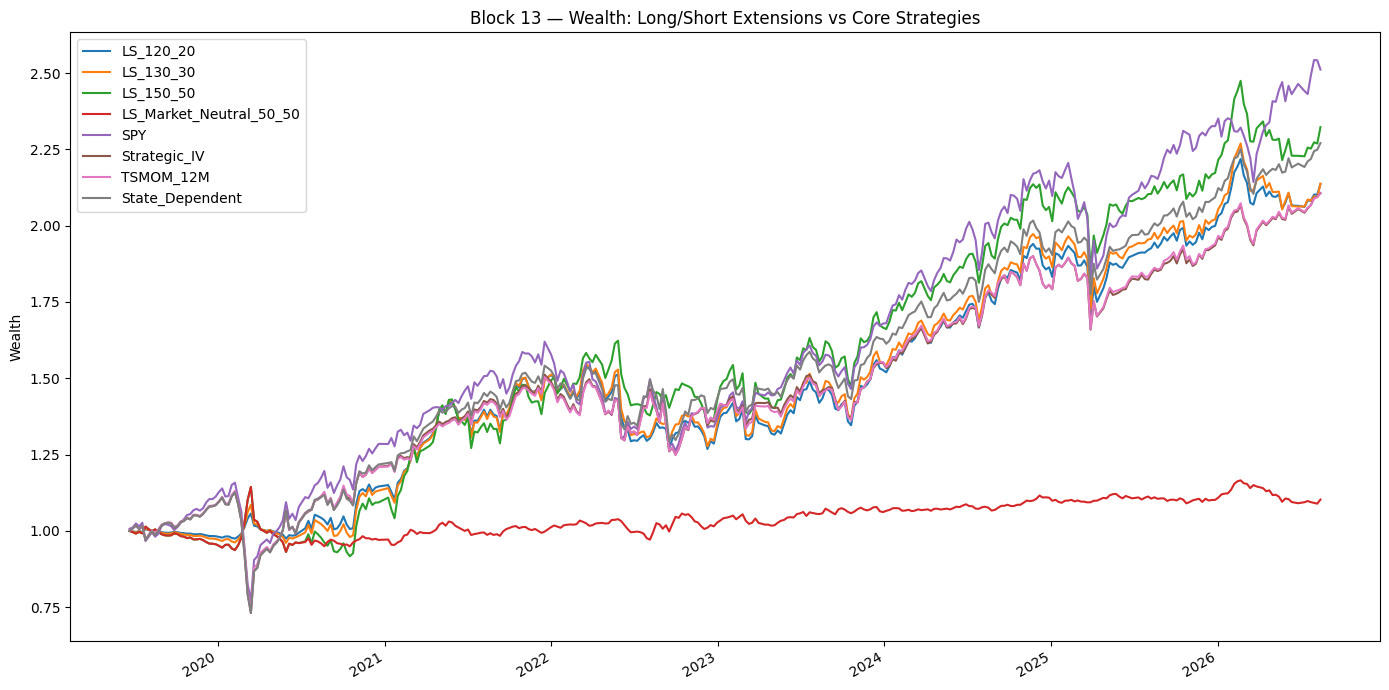

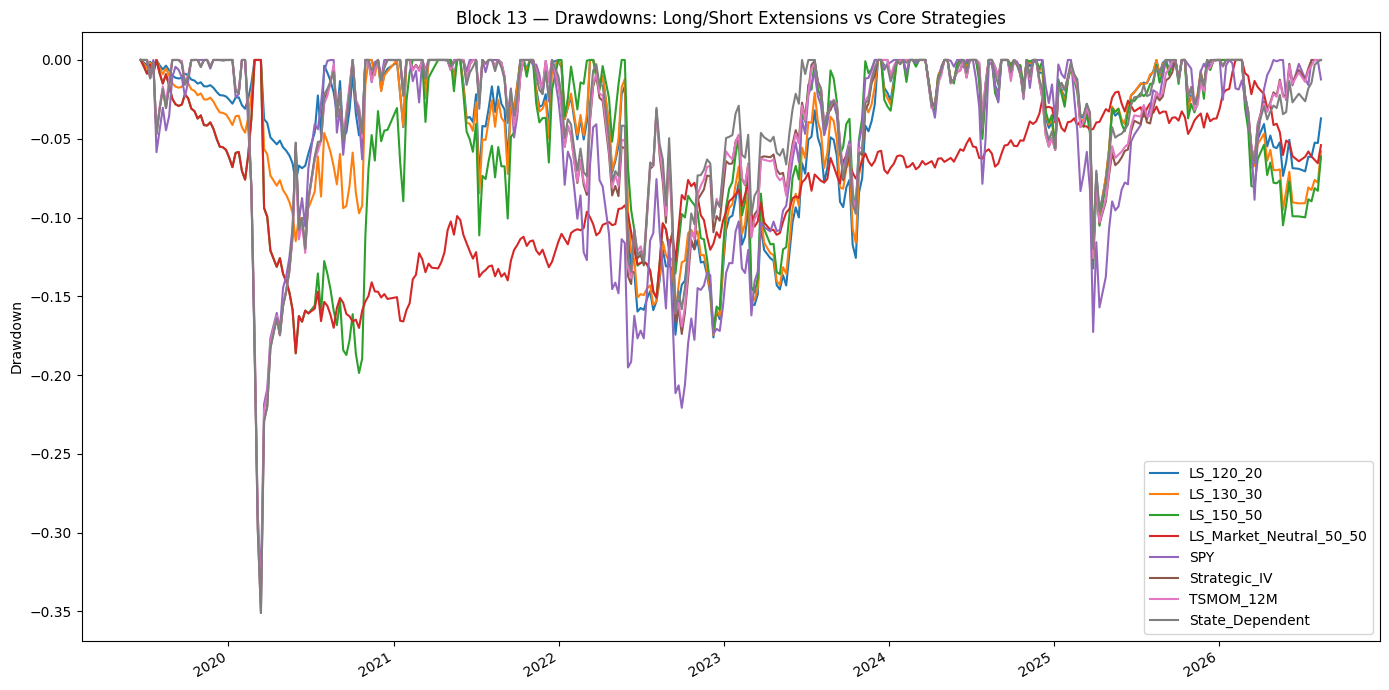

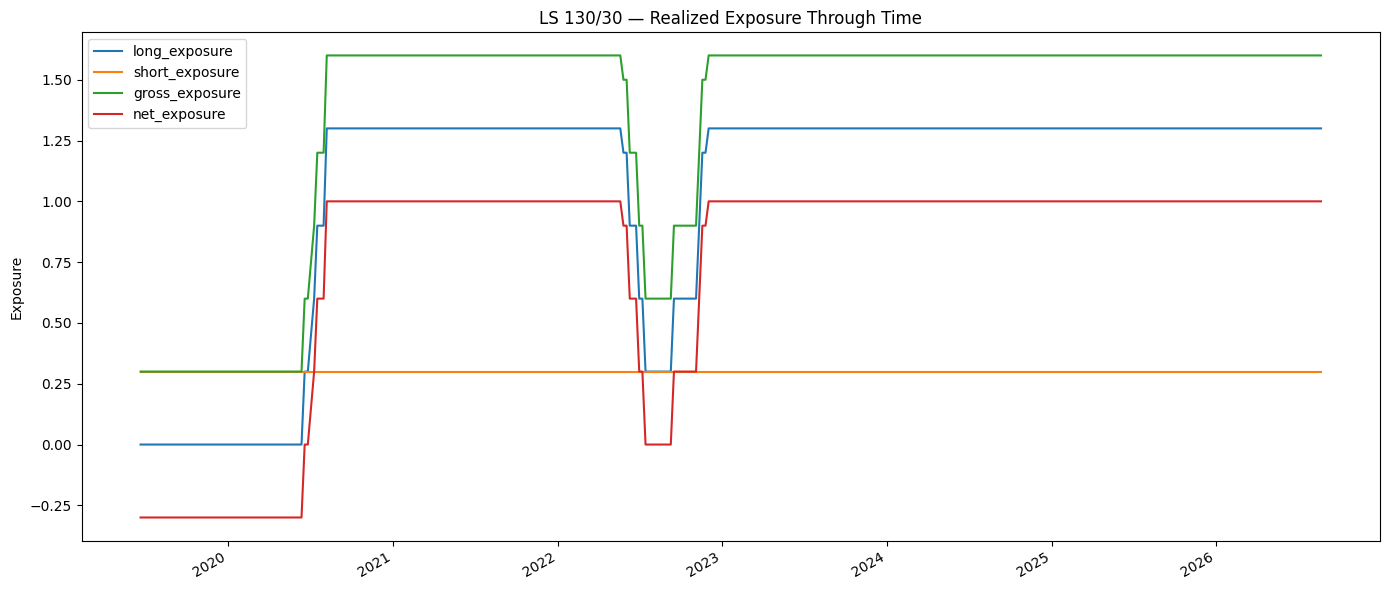

In [12]:
# ============================================================
# BLOCK 13.12 — COMPARISON FIGURES
# ============================================================

comparison = {}

for name, detail in ls_return_detail.items():
    comparison[name] = detail["net_return"]

for c in ["SPY", "Strategic_IV", "TSMOM_12M", "State_Dependent"]:
    if c in core_returns.columns:
        comparison[c] = core_returns[c]

common = pd.concat(comparison, axis=1).dropna()
wealth = (1.0 + common).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
wealth.plot(ax=ax)
ax.set_title("Block 13 — Wealth: Long/Short Extensions vs Core Strategies")
ax.set_ylabel("Wealth")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "block_13_long_short_wealth.png", dpi=180)
plt.show()

drawdowns = wealth.div(wealth.cummax()).sub(1.0)

fig, ax = plt.subplots(figsize=(14, 7))
drawdowns.plot(ax=ax)
ax.set_title("Block 13 — Drawdowns: Long/Short Extensions vs Core Strategies")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "block_13_long_short_drawdowns.png", dpi=180)
plt.show()

# Exposure diagnostics for 130/30.
d = ls_exposure_diag["LS_130_30"]

fig, ax = plt.subplots(figsize=(14, 6))
d[["long_exposure","short_exposure","gross_exposure","net_exposure"]].plot(ax=ax)
ax.set_title("LS 130/30 — Realized Exposure Through Time")
ax.set_ylabel("Exposure")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "block_13_130_30_exposure.png", dpi=180)
plt.show()


In [13]:
# ============================================================
# BLOCK 13.13 — RESEARCH DECISION TABLE
# ============================================================

decision_rows = []

for name in ls_performance.index:
    p = ls_performance.loc[name]
    d = ls_exposure_diag[name]

    decision_rows.append({
        "Architecture": name,
        "Net_CAGR": p["Net_CAGR"],
        "Net_Ann_Vol": p["Net_Ann_Vol"],
        "Net_Sharpe": p["Net_Sharpe"],
        "Net_Sortino": p["Net_Sortino"],
        "Net_MaxDD": p["Net_MaxDD"],
        "Net_Calmar": p["Net_Calmar"],
        "Avg_Gross_Exposure": d["gross_exposure"].mean(),
        "Avg_Net_Exposure": d["net_exposure"].mean(),
        "Maximum_Long_Sector_Weight": d["max_long_weight"].max(),
        "Maximum_Short_Sector_Abs_Weight": d["max_short_abs_weight"].max(),
        "Average_Number_Longs": d["n_long"].mean(),
        "Average_Number_Shorts": d["n_short"].mean(),
    })

decision = pd.DataFrame(decision_rows).set_index("Architecture")

display(decision)
decision.to_csv(OUTPUT_DIR / "block_13_long_short_decision_table.csv")


,Net_CAGR,Net_Ann_Vol,Net_Sharpe,Net_Sortino,Net_MaxDD,Net_Calmar,Avg_Gross_Exposure,Avg_Net_Exposure,Maximum_Long_Sector_Weight,Maximum_Short_Sector_Abs_Weight,Average_Number_Longs,Average_Number_Shorts
Architecture,,,,,,,,,,,,
LS_120_20,0.112027,0.138578,0.861512,1.115543,-0.176124,0.636068,1.178947,0.778947,0.3,0.128242,5.504155,5.495845
LS_130_30,0.112141,0.144945,0.830511,1.116270,-0.174659,0.642057,1.355679,0.755679,0.3,0.150000,5.504155,5.495845
LS_150_50,0.125142,0.165730,0.818275,1.160804,-0.198719,0.629741,1.671330,0.746953,0.3,0.150000,5.504155,5.495845
LS_Market_Neutral_50_50,0.013744,0.077489,0.220758,0.286625,-0.186215,0.073807,0.885457,-0.038920,0.3,0.150000,5.504155,5.495845


In [14]:
# ============================================================
# BLOCK 13.14 — MANIFEST & COMPLETION
# ============================================================

manifest = {
    "block": 13,
    "title": "Long/Short & Risk-Scaled Portfolio Extensions",
    "research_status": "EXTENSION_TO_FROZEN_BLOCKS_1_12",
    "signal_reoptimized": False,
    "fixed_long_short_books": FIXED_BOOKS,
    "portfolio_constraints": {
        "max_single_long_weight": MAX_SINGLE_LONG_WEIGHT,
        "max_single_short_abs_weight": MAX_SINGLE_SHORT_ABS_WEIGHT,
        "max_gross_exposure": MAX_GROSS_EXPOSURE,
    },
    "base_cost_assumptions": {
        "transaction_cost_bps": TRANSACTION_COST_BPS,
        "financing_rate_annual": FINANCING_RATE_ANNUAL,
        "short_borrow_rate_annual": SHORT_BORROW_RATE_ANNUAL,
    },
    "volatility_scaling": {
        "lookback_weeks": VOL_LOOKBACK_WEEKS,
        "targets": VOL_TARGETS,
        "leverage_cap": VOL_LEVERAGE_CAP,
        "lagged_estimator": True,
    },
    "outputs": [
        "block_13_bearish_state_forward_return_diagnostic.csv",
        "block_13_fixed_long_short_performance.csv",
        "block_13_volatility_scaled_performance.csv",
        "block_13_long_short_cost_sensitivity.csv",
        "block_13_long_short_decision_table.csv",
        "block_13_long_short_wealth.png",
        "block_13_long_short_drawdowns.png",
        "block_13_130_30_exposure.png",
    ],
}

with open(OUTPUT_DIR / "block_13_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

status = pd.DataFrame({
    "Block 13 status": [
        "Blocks 1–12 altered",
        "Signal parameters optimized",
        "Bearish short diagnostic saved",
        "Fixed long/short portfolios tested",
        "Market-neutral diagnostic tested",
        "Financing & borrow costs modeled",
        "Volatility scaling uses lagged volatility",
        "Cost sensitivity saved",
        "Decision table saved",
        "All figures saved",
    ],
    "Value": [
        False,
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
    ],
})

display(status)

print("\nBLOCK 13 COMPLETE")
print("Next: assess whether the bearish state contains genuine short-side alpha")
print("and whether long/short financing improves the frozen architecture.")


,Block 13 status,Value
0,Blocks 1–12 altered,False
1,Signal parameters optimized,False
2,Bearish short diagnostic saved,True
3,Fixed long/short portfolios tested,True
4,Market-neutral diagnostic tested,True
5,Financing & borrow costs modeled,True
6,Volatility scaling uses lagged volatility,True
7,Cost sensitivity saved,True
8,Decision table saved,True
9,All figures saved,True



BLOCK 13 COMPLETE
Next: assess whether the bearish state contains genuine short-side alpha
and whether long/short financing improves the frozen architecture.
